In [1]:
import sys
sys.path.append('..')
from osp import *

In [2]:
len(get_parsed_slice_ids(_force=True))

75495

In [3]:
gen_all_slice_feats(num_proc=8)

100%|██████████| 8491/8491 [06:02<00:00, 23.43it/s]


In [10]:
# get_parsed_slice_ids(_force=True)

In [11]:
# dfx = get_all_feats_stashed(_force=True)

In [12]:
# df_preds, df_feats, d_models = classify_then_predict_group(
#     groups_train,
#     target_col='discipline',
#     balance=True,
#     num_runs=10,
#     verbose=True,
#     return_models=True,
# )

In [13]:
# df_feats.sort_values('weight', ascending=False, inplace=True)
# df_feats

In [5]:
df_meta = get_corpus_metadata()
periods = sorted(df_meta.period.unique())
disciplines = ['Philosophy', 'Literature', 'Other']

In [7]:
comparisons = []
done = set()
for d1_i in range(len(disciplines)):
    d1 = disciplines[d1_i]
    for d2_i in range(len(disciplines)):
        d2 = disciplines[d2_i]
        
        for period1 in periods:
            for period2 in periods:
                if period1==period2 and d1==d2: continue

                key = tuple(sorted([period1, period2, d1, d2]))
                if key in done: continue
                done.add(key)

                name1 = f"{period1} {d1}"
                name2 = f"{period2} {d2}"
                name = f"{name1} vs {name2}"
                query1 = f'discipline=="{d1}" & period=="{period1}"'
                query2 = f'discipline=="{d2}" & period=="{period2}"'
                comparisons.append(((name1, query1), (name2, query2)))

len(comparisons)

75

In [8]:
df_preds, df_feats = classify_then_predict_comparisons(
    comparisons, 
    also_predict_unseen=True, 
    num_runs=10, 
    sample_size=1000, 
    feat_n=25,
    feat_n_egs=10, 
    normalize=NORMALIZE_CLASSIFY_DATA
)

Classifying comparisons: 100%|██████████| 75/75 [10:49<00:00,  8.66s/it]


In [9]:
df_preds.columns

Index(['true_label', 'pred_label', 'prob_1900-1925 Philosophy',
       'prob_1925-1950 Philosophy', 'test_label', 'confidence', 'correct',
       'accuracy', 'support', 'run', 'predict_type', 'comparison',
       'prob_1950-1975 Philosophy', 'prob_1975-2000 Philosophy',
       'prob_2000-2025 Philosophy', 'prob_1900-1925 Literature',
       'prob_1925-1950 Literature', 'prob_1950-1975 Literature',
       'prob_1975-2000 Literature', 'prob_2000-2025 Literature',
       'prob_1900-1925 Other', 'prob_1925-1950 Other', 'prob_1950-1975 Other',
       'prob_1975-2000 Other', 'prob_2000-2025 Other'],
      dtype='object')

In [10]:
df_probs = df_preds.query('predict_type=="unseen"').reset_index().groupby(['id','comparison']).mean(numeric_only=True).reset_index()

In [11]:
o = []
for i,row in tqdm(df_probs.iterrows(), total=len(df_probs)):
    id = row['id']
    cmp = row['comparison']
    name1, name2 = cmp.split(' vs ')
    prob1 = row['prob_'+name1]
    prob2 = row['prob_'+name2]
    outd = {'id':id, 'comparison':cmp}
    if prob1 > prob2:
        outd['pred'] = name1.split(' ',1)[-1]
        outd['prob'] = prob1
    else:
        outd['pred'] = name2.split(' ',1)[-1]
        outd['prob'] = prob2
    o.append(outd)
df_probs2 = pd.DataFrame(o)
df_probs2


100%|██████████| 2886018/2886018 [00:42<00:00, 68132.09it/s]


,id,comparison,pred,prob
0,lit/10.1086/341235__06,1900-1925 Literature vs 1900-1925 Other,Literature,0.990452
1,lit/10.1086/341235__06,1900-1925 Literature vs 1925-1950 Literature,Literature,0.871950
2,lit/10.1086/341235__06,1900-1925 Literature vs 1925-1950 Other,Literature,0.973377
3,lit/10.1086/341235__06,1900-1925 Literature vs 1950-1975 Literature,Literature,0.686595
4,lit/10.1086/341235__06,1900-1925 Literature vs 1950-1975 Other,Literature,0.934320
...,...,...,...,...
2886013,phil/10.2307/48761525__05,1975-2000 Philosophy vs 2000-2025 Other,Other,0.619415
2886014,phil/10.2307/48761525__05,1975-2000 Philosophy vs 2000-2025 Philosophy,Philosophy,0.954508
2886015,phil/10.2307/48761525__05,2000-2025 Literature vs 2000-2025 Other,Other,0.590371
2886016,phil/10.2307/48761525__05,2000-2025 Philosophy vs 2000-2025 Literature,Philosophy,0.915181


In [12]:
df_probs2.to_pickle('../data/raw/df_probs.pkl.gz')

In [13]:
df_feats['weight_abs'] = df_feats['weight'].abs()
df_feats.groupby('feature').mean(numeric_only=True).sort_values('weight_abs', ascending=False)

,weight,mean_1900-1925 Philosophy,mean_1925-1950 Philosophy,run,mean_1950-1975 Philosophy,mean_1975-2000 Philosophy,mean_2000-2025 Philosophy,mean_1900-1925 Literature,mean_1925-1950 Literature,mean_1950-1975 Literature,mean_1975-2000 Literature,mean_2000-2025 Literature,mean_1900-1925 Other,mean_1925-1950 Other,mean_1950-1975 Other,mean_1975-2000 Other,mean_2000-2025 Other,weight_abs
feature,,,,,,,,,,,,,,,,,,
deprel_compound,0.993011,-0.684624,-0.655721,4.5,-0.488993,-0.162390,0.227276,-0.447634,-0.421037,-0.424866,-0.381393,0.162126,0.322739,0.580218,0.852881,1.476123,2.187198,1.258042
pos_POS,0.167355,-0.517049,-0.473206,4.5,-0.240020,0.032969,-0.304501,0.278742,0.559919,0.766667,0.859946,0.452165,-0.523513,-0.452405,-0.338964,-0.159316,-0.436697,0.480703
pos_VB,0.318323,0.026383,-0.025544,4.5,0.400495,0.510708,0.466354,-0.596078,-0.586694,-0.573366,-0.497866,-0.597111,-0.524051,-0.517245,-0.516421,-0.329121,-0.630126,0.469692
pos_NN,0.143526,0.126008,0.070771,4.5,-0.125446,-0.006320,0.093030,-0.742633,-0.806659,-0.333701,-0.013357,0.072713,-0.101480,-0.102285,0.260261,0.515901,0.681764,0.463340
deprel_cop,-0.269769,0.287215,0.398654,4.5,0.541017,0.434839,0.438985,-0.540919,-0.485244,-0.397807,-0.542658,-0.760237,-0.656002,-0.656867,-0.571635,-0.704081,-0.981115,0.450637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
deprel_dep,0.046483,-0.188643,-0.225978,4.5,-0.134341,-0.098636,0.010643,0.294988,0.230683,0.162281,-0.023290,0.136157,0.018850,0.008032,0.119526,0.046100,0.261315,0.132680
deprel_csubj:outer,0.044833,0.000441,0.011453,4.5,0.185697,0.108550,-0.001809,-0.122964,-0.145569,-0.083546,0.016461,-0.016636,-0.164129,-0.186103,-0.132506,-0.131969,-0.098560,0.123284
pos_RBS,0.006171,0.165721,0.043770,4.5,-0.103323,-0.153557,-0.195140,0.139853,0.222859,0.332392,0.204656,0.170510,0.104437,0.093799,0.121962,0.170723,-0.006684,0.121753


In [ ]:
odf = df_preds.groupby('comparison').mean(numeric_only=True)
# odf

In [92]:
figdf = odf.reset_index()
figdf['comparison'] = pd.Categorical(figdf['comparison'], categories=figdf['comparison'].unique()[::-1])

def cmptype(cmp):
    x,y = cmp.split(' vs ')
    x1,x2 = x.split(' ')
    y1,y2 = y.split(' ')
    if y2<x2: return None
    return f'{x2} vs {y2}'
    # return 'Philosophy vs X' if 'Philosophy' in cmp else 'X vs X'

def periodtype(cmp):
    x,y = cmp.split(' vs ')
    x1,x2 = x.split(' ')
    y1,y2 = y.split(' ')
    return f'{y1.split("-")[0]} vs {x1.split("-")[0]}'

def perioddist(cmp):
    x,y = cmp.split(' vs ')
    x1,x2 = x.split(' ')
    y1,y2 = y.split(' ')
    xx1 = int(x1.split('-')[0])
    yy1 = int(y1.split('-')[0])
    return abs(xx1-yy1)

figdf['cmp_type'] = figdf['comparison'].map(cmptype)
figdf['period_type'] = figdf['comparison'].map(periodtype)
figdf['period_dist'] = figdf['comparison'].map(perioddist)

figdf = figdf[figdf['cmp_type'].notna()]
figdf['correct_str'] = (figdf['correct']*100).round(1).astype(str)+'%'
figdf['correct']*=100
figdf['cmp_type'] = pd.Categorical(figdf['cmp_type'], categories=figdf.groupby('cmp_type').mean(numeric_only=True).sort_values('correct', ascending=False).index)

In [93]:
# figdf.groupby('cmp_type').mean(numeric_only=True)

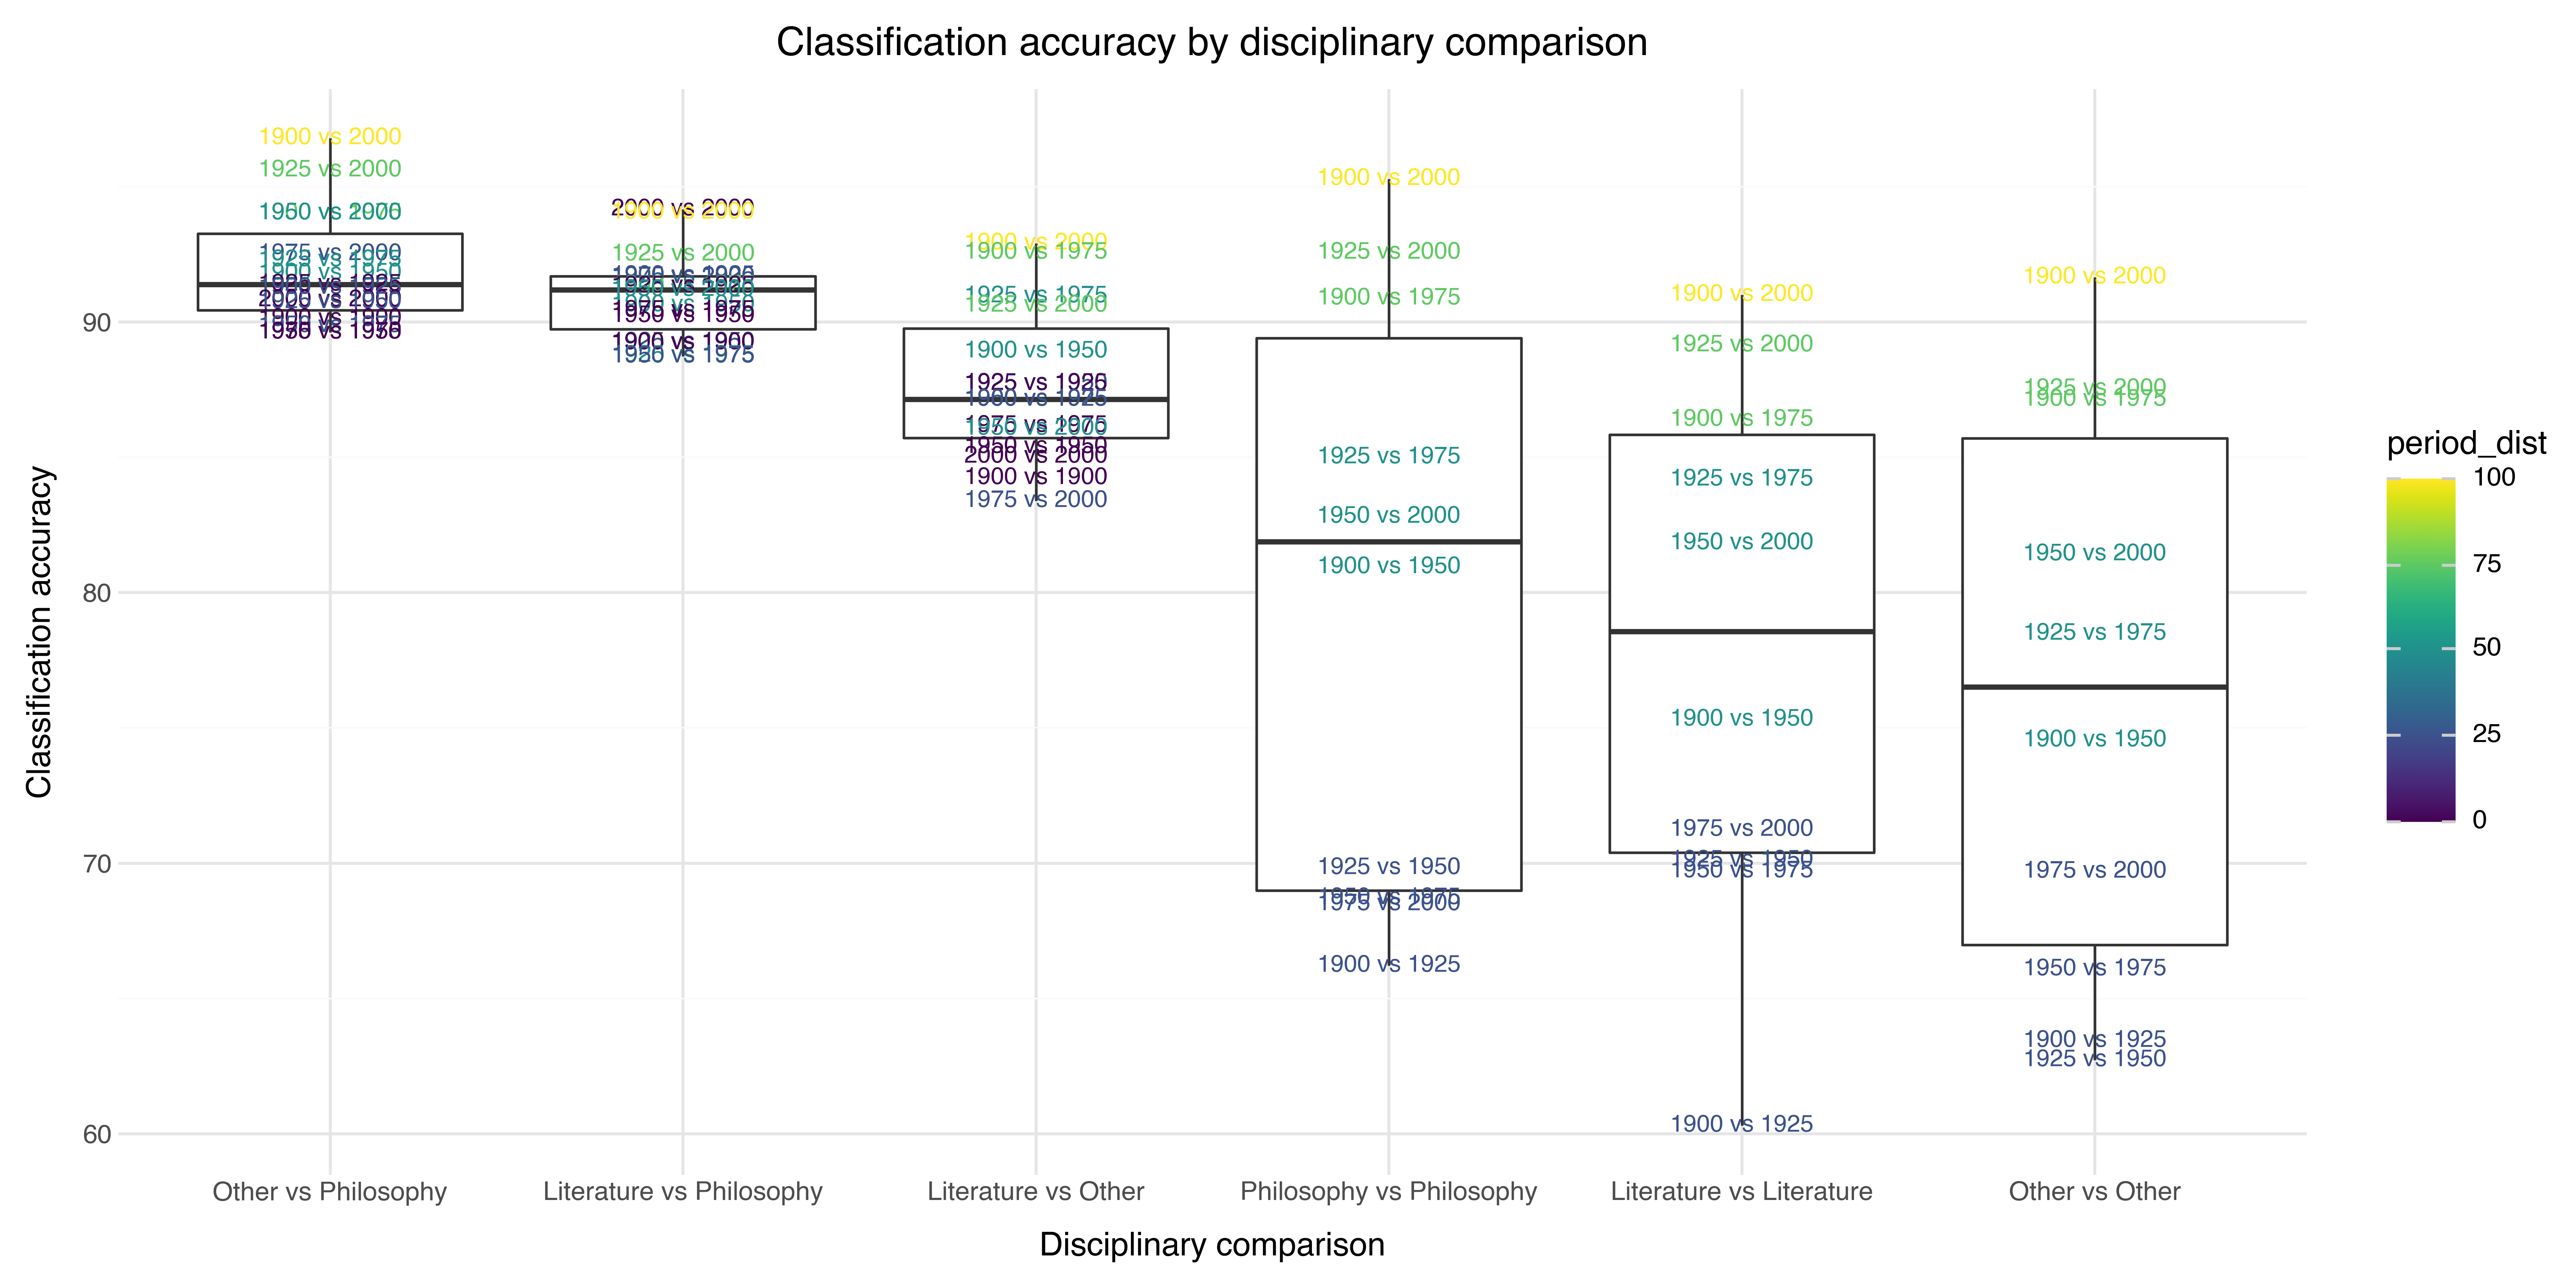

In [98]:
fig = (
    p9.ggplot(
        figdf,
        p9.aes(x='cmp_type', y='correct', label='period_type')
    ) 
    + p9.geom_boxplot() 
    + p9.theme_minimal() 
    + p9.theme(figure_size=(12, 6)) 
    + p9.geom_text(p9.aes(color='period_dist'), size=8)
    # + p9.scale_y_continuous(limits=(50, 100))
    + p9.labs(x='Disciplinary comparison', y='Classification accuracy', title='Classification accuracy by disciplinary comparison')
)
fig

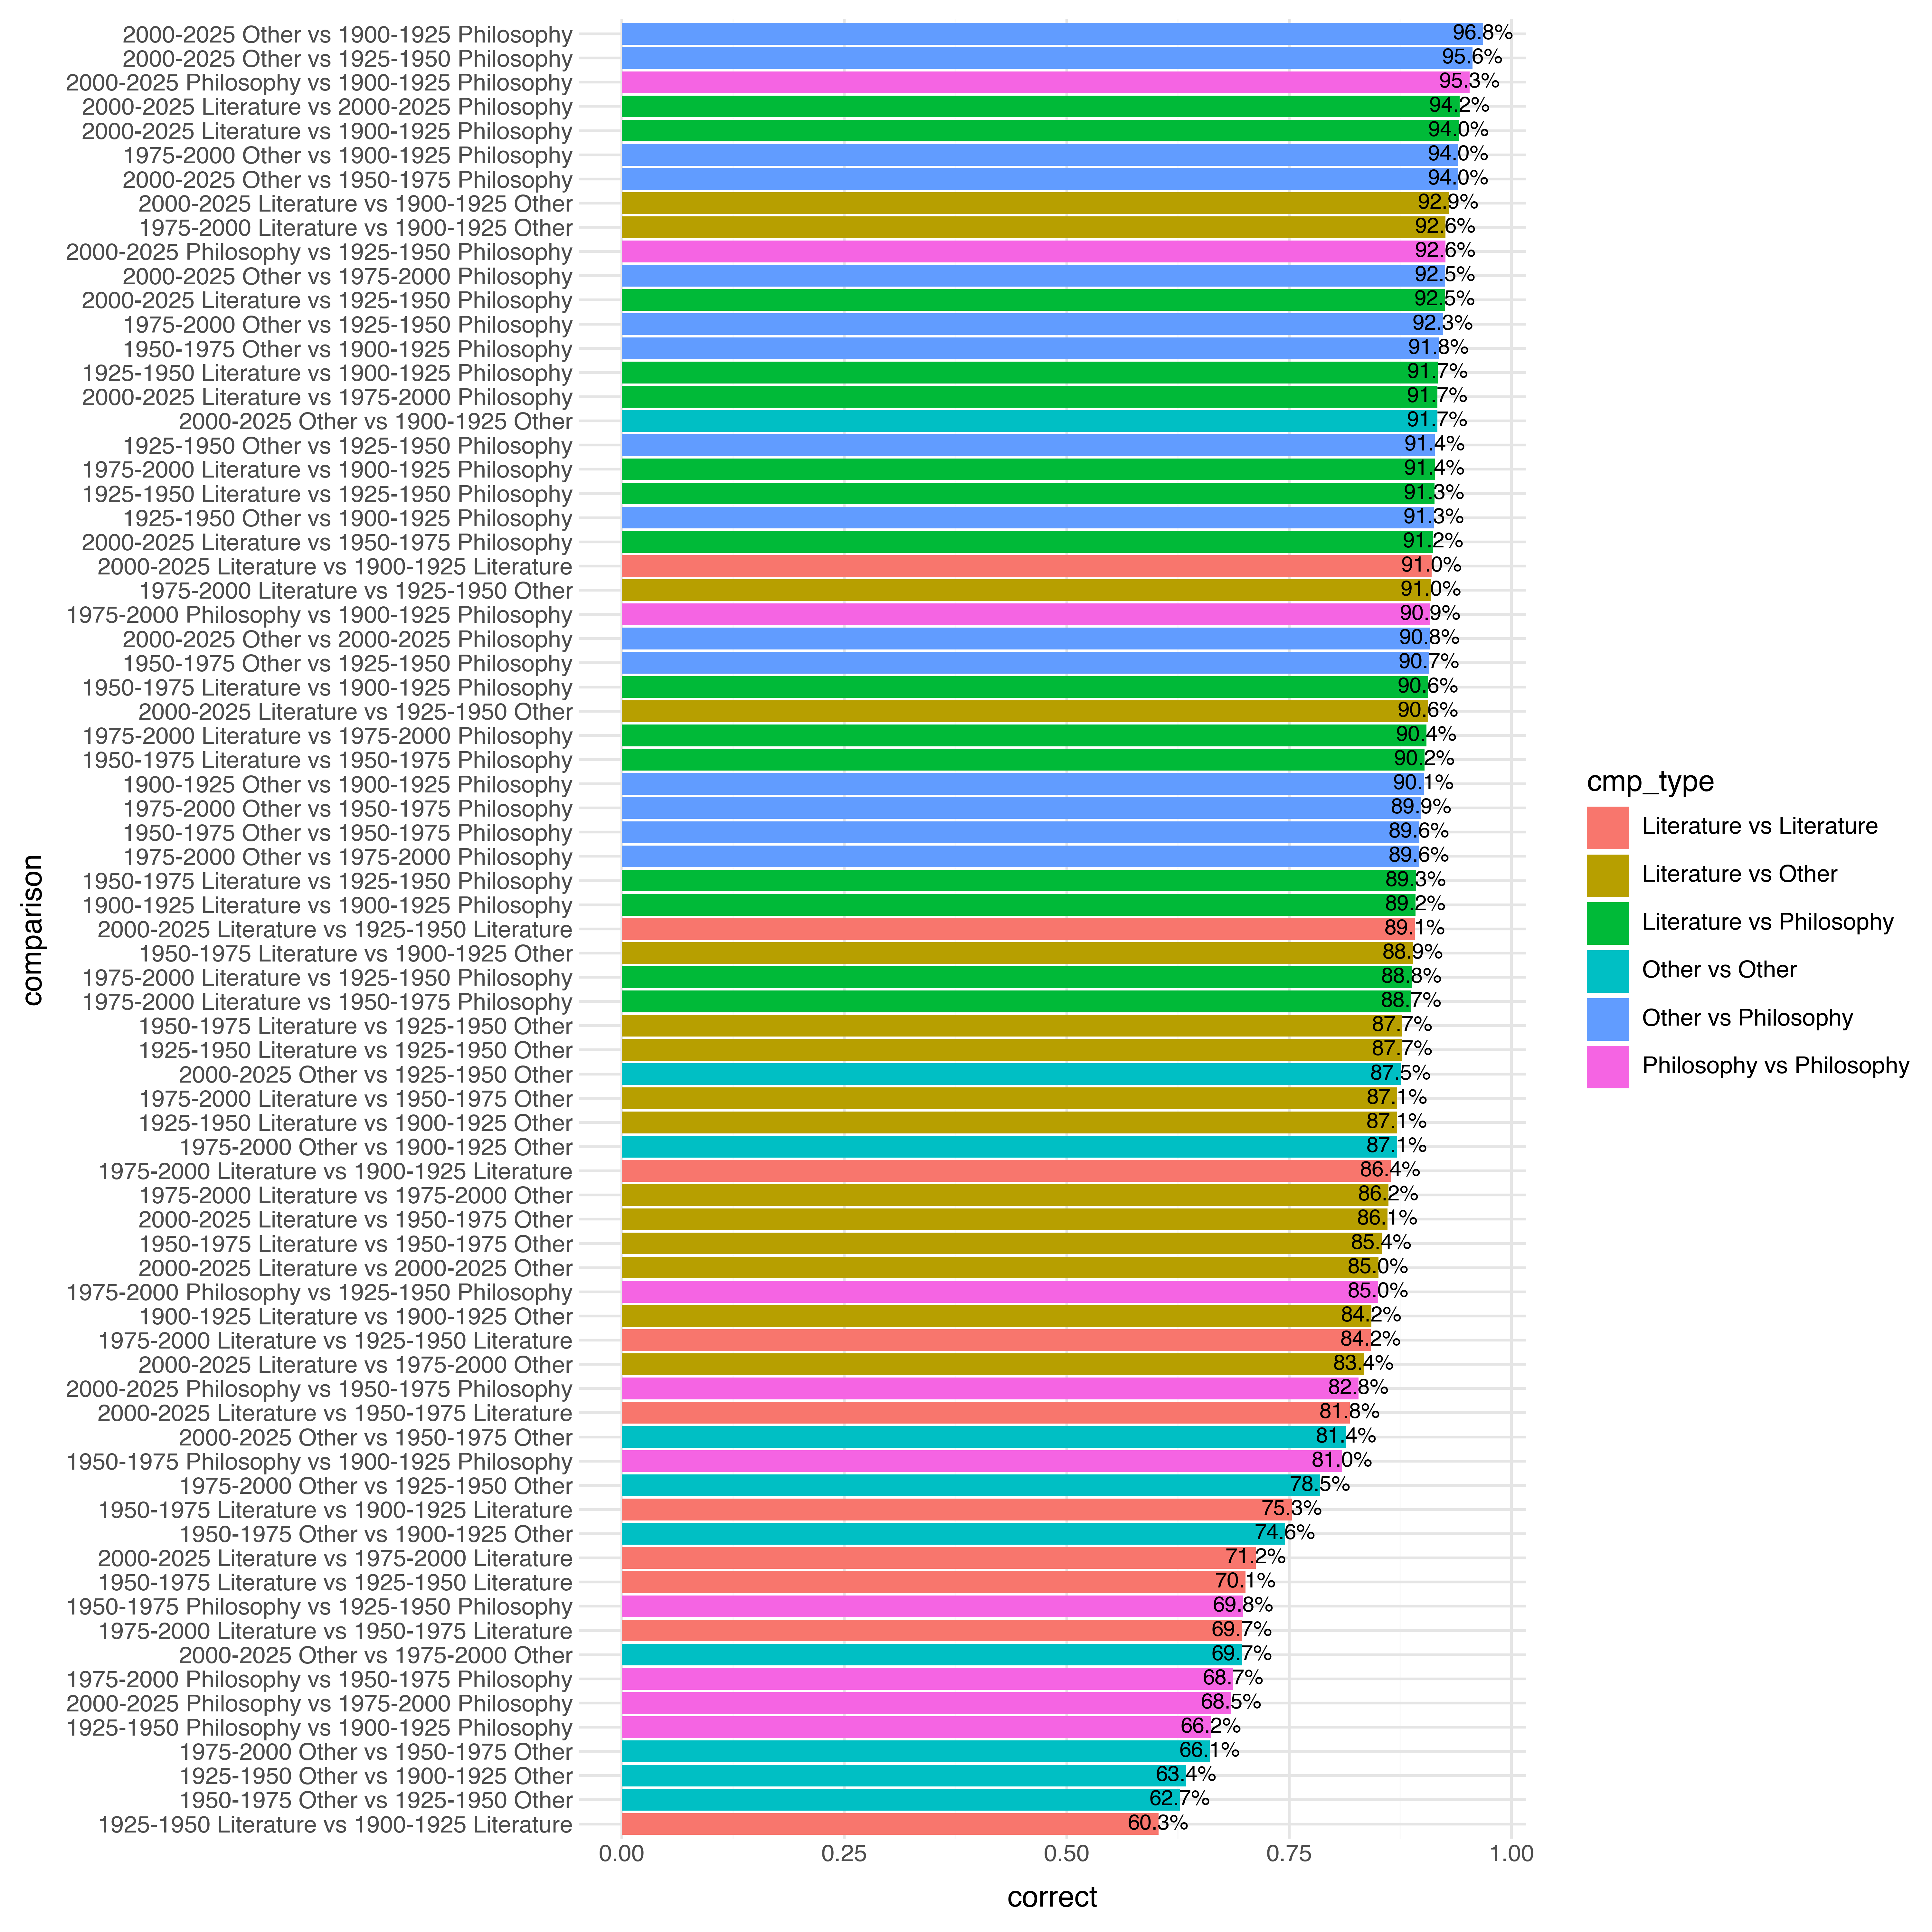

In [69]:

fig = p9.ggplot(figdf, p9.aes(x='comparison', y='correct', fill='cmp_type', label='correct_str')) + p9.geom_bar(stat='identity') + p9.theme_minimal() + p9.coord_flip() + p9.theme(
    figure_size=(10, 10),
) + p9.geom_text(size=8)
fig